In [31]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [32]:
# Define variables
PERIOD = 200
STARTING_BALANCE = 10000

In [33]:
price = yf.download("AVGO",start="2005-01-01",end="2015-01-01")
YEARS = 10

price.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AVGO,AVGO,AVGO,AVGO,AVGO
Date,,,,,
2009-08-06,1.137389,1.188705,1.093805,1.159883,241978000
2009-08-07,1.154962,1.178160,1.126844,1.135279,24543000
2009-08-10,1.122626,1.169022,1.097320,1.169022,24210000
2009-08-11,1.101538,1.124735,1.089587,1.123329,23054000
2009-08-12,1.124735,1.138794,1.100834,1.135279,14513000


In [34]:
# drop redundanct columns
price = price.drop(["High","Low","Volume"],axis=1)
price.head()

Price,Close,Open
Ticker,AVGO,AVGO
Date,,
2009-08-06,1.137389,1.159883
2009-08-07,1.154962,1.135279
2009-08-10,1.122626,1.169022
2009-08-11,1.101538,1.123329
2009-08-12,1.124735,1.135279


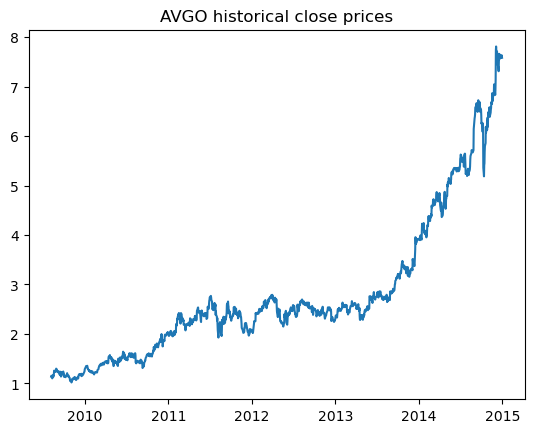

In [35]:
#plot chart
plt.plot(price["Close"]["AVGO"])
plt.title("AVGO historical close prices")
plt.show()

In [36]:
# calculate daily return
price["Return"] = price["Close"] / price["Open"]
price["Bench_Bal"] = STARTING_BALANCE * price.Return.cumprod()
price.head()

Price,Close,Open,Return,Bench_Bal
Ticker,AVGO,AVGO,,
Date,,,,
2009-08-06,1.137389,1.159883,0.980606,9806.060933
2009-08-07,1.154962,1.135279,1.017337,9976.073116
2009-08-10,1.122626,1.169022,0.960313,9580.149678
2009-08-11,1.101538,1.123329,0.980601,9394.301865
2009-08-12,1.124735,1.135279,0.990712,9307.048371


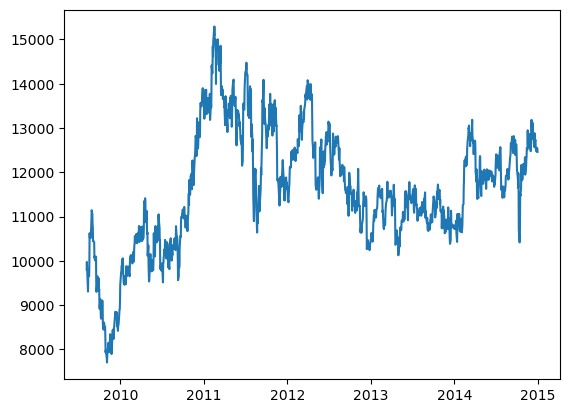

In [37]:
plt.plot(price.Bench_Bal)
plt.show()

In [43]:
# calculating metrices
bench_return = round(((price.Bench_Bal[-1] / price.Bench_Bal[0])-1)*100,2)
bench_cagr = round((((price.Bench_Bal[-1] / price.Bench_Bal[0])**(1/YEARS))-1)*100,2)
print(bench_return)
print(bench_cagr)

27.09
2.43


/tmp/ipykernel_6182/458252796.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bench_return = round(((price.Bench_Bal[-1] / price.Bench_Bal[0])-1)*100,2)
/tmp/ipykernel_6182/458252796.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bench_cagr = round((((price.Bench_Bal[-1] / price.Bench_Bal[0])**(1/YEARS))-1)*100,2)


In [45]:
# calculate 
price["Bench_Peak"] = price.Bench_Bal.cummax()
price["Bench_DD"] = price.Bench_Bal - price.Bench_Peak

bench_dd = round(((price.Bench_DD / price.Bench_Peak).min())*100,2)

In [46]:
print(bench_dd)

-33.78
